In [1]:
import json

from Eval import eval_answer

Did not find file example.env.
This is used to double check the key settings for the notebook.
This is just a check and is not required.



In [2]:
data_experiment=eval_answer()
data_60_examples=eval_answer(flag=True)

In [3]:
import pandas as pd
Data_experiment = pd.DataFrame(data_experiment)
Data_experiment.head()

,correctness,duration,type_,Crossed_edges,no_of_edges,no_of_nodes,model
0,1,1.124367,DI,no,3,4,Qwen/Qwen2.5-7B-Instruct:together
1,0,0.881759,mixed,no,3,4,Qwen/Qwen2.5-7B-Instruct:together
2,0,1.291369,inDI,no,3,4,Qwen/Qwen2.5-7B-Instruct:together
3,0,0.894541,DI,True,3,4,Qwen/Qwen2.5-7B-Instruct:together
4,0,1.762372,mixed,True,3,4,Qwen/Qwen2.5-7B-Instruct:together


In [4]:
overall = Data_experiment.groupby('model')['correctness'].mean().reset_index()   
overall.head()

,model,correctness
0,Qwen/Qwen2.5-7B-Instruct:together,0.055556
1,Qwen/Qwen3-235B-A22B-Instruct-2507:novita,0.111111
2,deepseek-ai/DeepSeek-V3.2-Exp:novita,0.166667
3,deepseek-ai/DeepSeek-V3.2:novita,0.111111
4,deepseek-r1,0.055556


In [5]:
overall = Data_experiment.groupby(['model','type_'])['correctness'].mean().reset_index()   
overall.head()

,model,type_,correctness
0,Qwen/Qwen2.5-7B-Instruct:together,DI,0.166667
1,Qwen/Qwen2.5-7B-Instruct:together,inDI,0.000000
2,Qwen/Qwen2.5-7B-Instruct:together,mixed,0.000000
3,Qwen/Qwen3-235B-A22B-Instruct-2507:novita,DI,0.333333
4,Qwen/Qwen3-235B-A22B-Instruct-2507:novita,inDI,0.000000


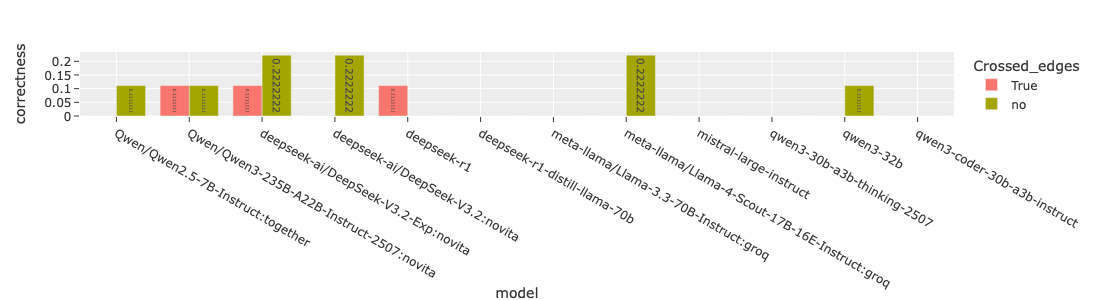

In [6]:
overall = Data_experiment.groupby(['model','Crossed_edges'])['correctness'].mean().reset_index()   
overall.head()

import plotly.express as px
template='ggplot2'
df = overall
fig = px.bar(df, x="model", y="correctness",
             color='Crossed_edges', barmode='group',template=template,text_auto=True,
             height=300)
fig.show()
fig.write_image("images/duration_di_indi.png")

In [7]:
import pandas as pd
Data_60 = pd.DataFrame(data_60_examples)
Data_60.head()

,correctness,duration,type_,Crossed_edges,no_of_edges,no_of_nodes,model
0,0,0.673245,,True,3,3,meta-llama/Llama-4-Scout-17B-16E-Instruct:groq
1,0,0.492084,,True,3,3,meta-llama/Llama-4-Scout-17B-16E-Instruct:groq
2,0,0.441763,,True,4,3,meta-llama/Llama-4-Scout-17B-16E-Instruct:groq
3,0,0.444273,,True,4,3,meta-llama/Llama-4-Scout-17B-16E-Instruct:groq
4,0,0.592553,,True,5,3,meta-llama/Llama-4-Scout-17B-16E-Instruct:groq


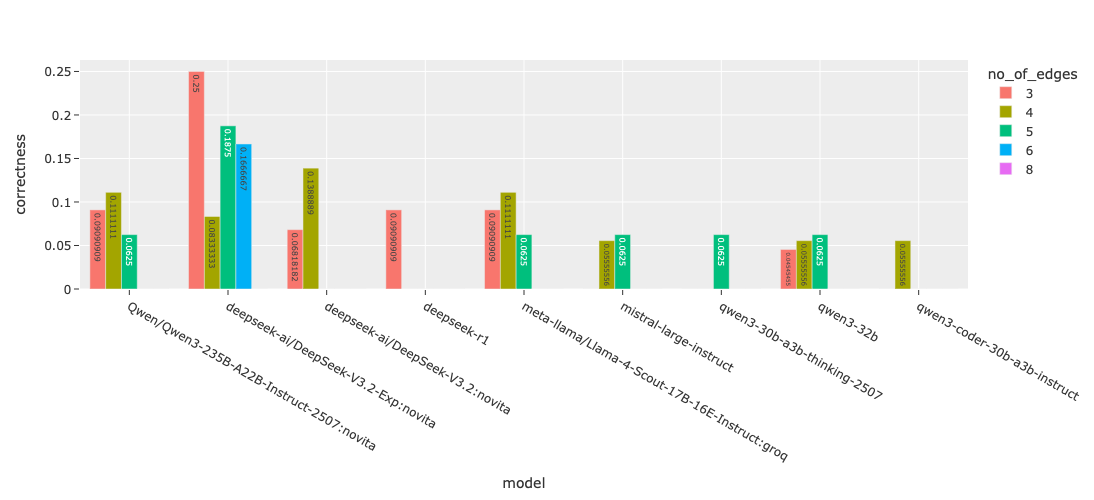

In [8]:
overall = Data_60.groupby(['model','no_of_edges'])['correctness'].mean().reset_index()   
overall.head()

import plotly.express as px
template='ggplot2'
df = overall
fig = px.bar(df, x="model", y="correctness",
             color='no_of_edges', barmode='group',template=template,text_auto=True,
             height=500)
fig.show()
fig.write_image("images/duration_di_indi.png")